# 04 — ML Classification Models (scikit-learn baseline)

A fast, lightweight comparison of **3 classification models** on the event-level features, using scikit-learn — useful as a quick baseline before the full PySpark MLlib pipeline.


In [1]:
import os, sys
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['HADOOP_HOME'] = r'C:\Hadoop'

In [2]:
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

df = pd.read_csv("data/event_level_features.csv").dropna(
    subset=["hour_of_day", "prev_headway_sec", "is_bunching"]
)

X = df[["hour_of_day", "prev_headway_sec"]]
y = df["is_bunching"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y if y.nunique() > 1 else None)
print("Train:", len(X_train), "| Test:", len(X_test))


Train: 259 | Test: 65


In [3]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}

results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    preds = model.predict(X_test)

    try:
        proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, proba) if y_test.nunique() > 1 else float("nan")
    except Exception:
        auc = float("nan")

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "roc_auc": auc,
        "train_time_sec": train_time,
    })

results_pdf = pd.DataFrame(results)
results_pdf["f1_per_sec"] = results_pdf["f1"] / results_pdf["train_time_sec"]
results_pdf


,model,accuracy,precision,recall,f1,roc_auc,train_time_sec,f1_per_sec
0,LogisticRegression,0.615385,0.200000,0.105263,0.137931,0.790618,0.167436,0.823783
1,RandomForest,0.861538,0.812500,0.684211,0.742857,0.856407,0.260498,2.851685
2,GradientBoosting,0.876923,0.866667,0.684211,0.764706,0.871281,0.212128,3.604932


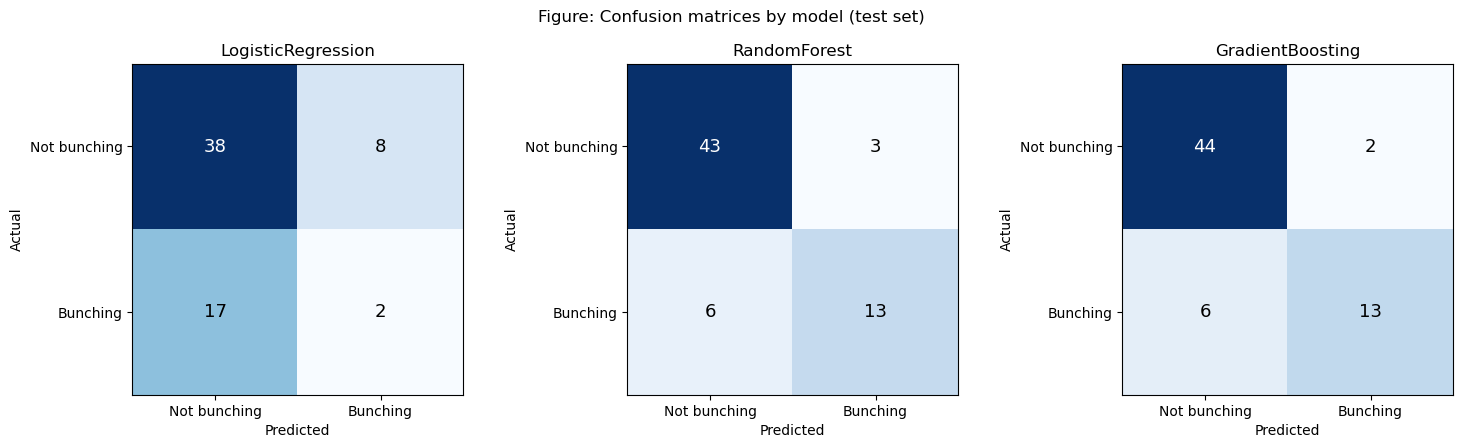

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve
import numpy as np

# Recompute predictions/probabilities for each fitted model (already trained above)
preds_store, proba_store = {}, {}
for name, model in models.items():
    preds_store[name] = model.predict(X_test)
    proba_store[name] = model.predict_proba(X_test)[:, 1]

# ---- Confusion matrices ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name in zip(axes, models.keys()):
    cm = confusion_matrix(y_test, preds_store[name])
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_xticks([0,1]); ax.set_xticklabels(["Not bunching","Bunching"])
    ax.set_yticks([0,1]); ax.set_yticklabels(["Not bunching","Bunching"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j], ha="center", va="center",
                     color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=13)
fig.suptitle("Figure: Confusion matrices by model (test set)")
plt.tight_layout()
plt.savefig("figure_confusion_matrices.png", dpi=150)
plt.show()


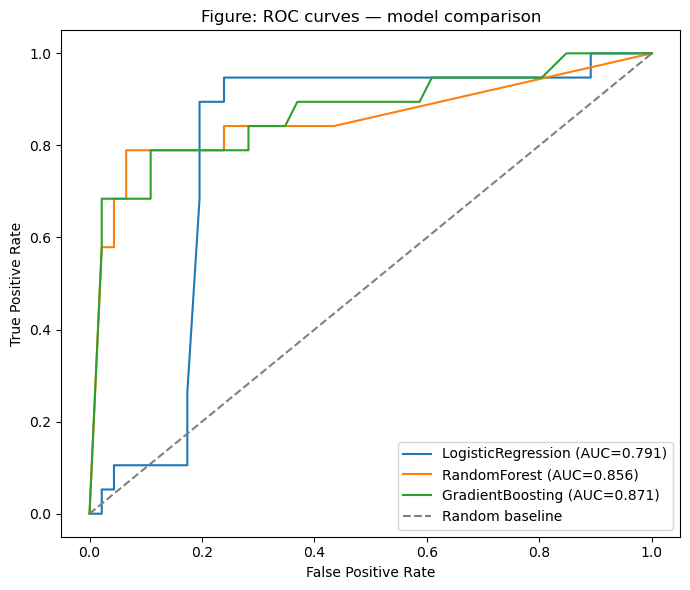

In [6]:

# ---- ROC curves ----
fig, ax = plt.subplots(figsize=(7,6))
for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, proba_store[name])
    auc = results_pdf.loc[results_pdf.model==name, "roc_auc"].values[0]
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0,1],[0,1], linestyle="--", color="gray", label="Random baseline")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Figure: ROC curves — model comparison")
ax.legend()
plt.tight_layout()
plt.savefig("figure_roc_curves.png", dpi=150)
plt.show()

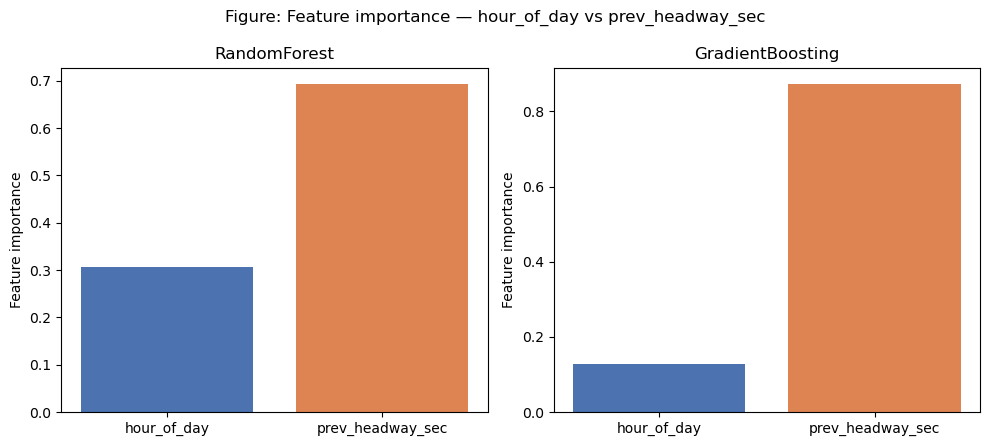

In [7]:
# ---- Feature importance (RF & GBT) ----
fig, axes = plt.subplots(1, 2, figsize=(10,4.5))
for ax, name in zip(axes, ["RandomForest", "GradientBoosting"]):
    importances = models[name].feature_importances_
    ax.bar(X.columns, importances, color=["#4C72B0","#DD8452"])
    ax.set_title(name); ax.set_ylabel("Feature importance")
fig.suptitle("Figure: Feature importance — hour_of_day vs prev_headway_sec")
plt.tight_layout()
plt.savefig("figure_feature_importance.png", dpi=150)
plt.show()

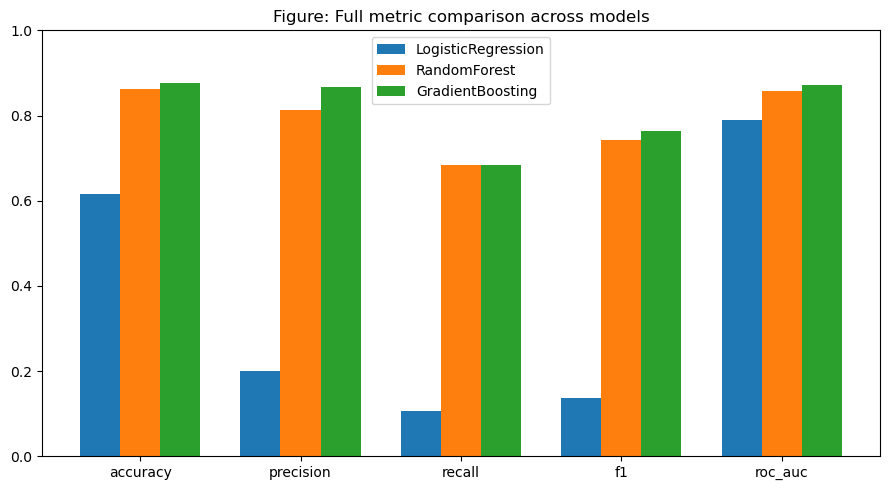

In [8]:

# ---- Grouped metric comparison ----
metrics = ["accuracy","precision","recall","f1","roc_auc"]
fig, ax = plt.subplots(figsize=(9,5))
x = np.arange(len(metrics))
width = 0.25
for i, name in enumerate(models.keys()):
    vals = results_pdf.loc[results_pdf.model==name, metrics].values.flatten()
    ax.bar(x + (i-1)*width, vals, width, label=name)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0,1)
ax.set_title("Figure: Full metric comparison across models")
ax.legend()
plt.tight_layout()
plt.savefig("figure_full_metric_comparison.png", dpi=150)
plt.show()

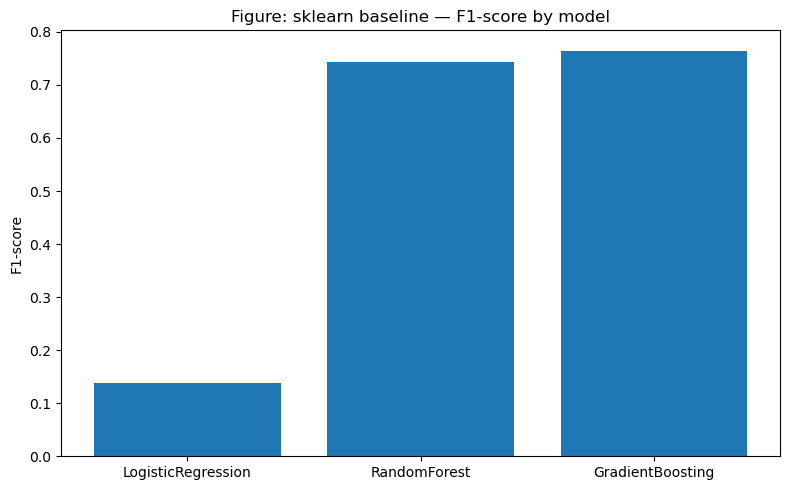

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(results_pdf["model"], results_pdf["f1"])
ax.set_title("Figure: sklearn baseline — F1-score by model")
ax.set_ylabel("F1-score")
plt.tight_layout()
plt.savefig("figure_sklearn_baseline_f1.png", dpi=150)
plt.show()

results_pdf.to_csv("data/sklearn_model_results.csv", index=False)
